Phase 1: Import and Load :

In [ ]:
# Install the library to read Excel files
!pip install pandas numpy matplotlib seaborn openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# The dataset has two sheets: 2009-2010 and 2010-2011
# We load both and stack them into one table
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

df = pd.concat([df1, df2], ignore_index=True)

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(df.head(3))


Dataset loaded: 1,067,371 rows, 8 columns
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  



💡 Note: pd.concat() stacks the two years vertically, and ignore_index=True renumbers the rows into one continuous timeline.

PHASE 2: DATA CLEANING

In [ ]:
print(f"Original shape: {df.shape}")

# 1. Remove rows with missing Customer ID
# These are guest checkouts. We can't track loyalty without an ID.
df_clean = df.dropna(subset=['Customer ID']).copy()

# 2. Remove rows with missing product description
df_clean = df_clean.dropna(subset=['Description'])

# 3. Remove exact duplicates (sometimes exports contain double entries)
df_clean = df_clean.drop_duplicates()

# 4. Create Revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean['Revenue'] = df_clean['Revenue'].round(2)

# 5. Remove rows where both Quantity AND Price are zero (pure junk)
df_clean = df_clean[~((df_clean['Quantity'] == 0) & (df_clean['Price'] == 0))]

# 6. Fix data types
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate']).dt.tz_localize(None)

print(f"Cleaned shape: {df_clean.shape}")
print(f"Unique customers: {df_clean['Customer ID'].nunique():,}")
print(f"Date range: {df_clean['InvoiceDate'].min().date()} to {df_clean['InvoiceDate'].max().date()}")


Original shape: (1067371, 8)
Cleaned shape: (797885, 9)
Unique customers: 5,942
Date range: 2009-12-01 to 2011-12-09



💡 Note: RFM analysis needs a Customer ID to track repeat buyers, so guest checkouts (missing IDs) cannot be used. Duplicate rows can come from refunds or export syncing issues, so they are removed to avoid double counting. tz_localize(None) removes timezone info so date arithmetic works correctly.

In [ ]:
print(f"Total Revenue: £{df_clean['Revenue'].sum():,.2f}")


Total Revenue: £16,289,991.27



PHASE 3: FEATURE ENGINEERING

In [ ]:
# Extract month for trend analysis
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# For the real dataset, Revenue is already created above
print("Features ready: InvoiceMonth, Revenue")


Features ready: InvoiceMonth, Revenue



PHASE 4: RFM ANALYSIS (The Core Deliverable)

RFM stands for Recency (how recently they bought), Frequency (how often), and Monetary (how much they spent). It segments customers by value without any complex math.

In [ ]:
# Reference date = day after the last transaction in the dataset
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate the three metrics per customer
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                     # Frequency (unique orders)
    'Revenue': 'sum'                                           # Monetary
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# Remove return-only customers (negative lifetime value)
rfm = rfm[rfm['Monetary'] > 0].copy()
rfm['Monetary'] = rfm['Monetary'].round(2)

# Score each customer from 1 (worst) to 5 (best) within quintiles
# Recency: LOWER days = HIGHER score (bought recently)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)

# Frequency: HIGHER count = HIGHER score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

# Monetary: HIGHER spend = HIGHER score
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

# Business-friendly segments
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Promising'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Show the breakdown
print(rfm['Segment'].value_counts())
print("\nAverage metrics by segment:")
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))


Segment
Champions           1285
Lost                1264
Loyal Customers     1143
At Risk              836
Others               620
New Promising        461
Cannot Lose Them     230
Name: count, dtype: int64

Average metrics by segment:
                  Recency  Frequency  Monetary
Segment                                       
At Risk             360.4        6.1    1667.4
Cannot Lose Them    413.5        1.8    1205.0
Champions            18.6       21.1    8874.0
Lost                463.1        1.3     248.9
Loyal Customers      70.5        7.1    2155.1
New Promising        26.0        1.6     529.8
Others               86.9        2.4     461.9



💡 Note: qcut splits customers into 5 equal sized groups per metric. Recency labels are reversed (5 to 1) since a smaller number of days since purchase is a better score. The segment_customer function turns the three numeric scores into named categories that are easier to act on than raw numbers.

PHASE 5: COHORT ANALYSIS (Retention)

This shows what percentage of customers from each "starting month" came back in month 1, 2, 3, etc. It proves you can measure loyalty over time.

In [ ]:
# Find the first purchase month for every customer
df_clean['CohortMonth'] = df_clean.groupby('Customer ID')['InvoiceMonth'].transform('min')

# Calculate how many months have passed since first purchase
invoice_year = df_clean['InvoiceMonth'].dt.year
invoice_month = df_clean['InvoiceMonth'].dt.month
cohort_year = df_clean['CohortMonth'].dt.year
cohort_month = df_clean['CohortMonth'].dt.month

df_clean['PeriodNumber'] = (invoice_year - cohort_year) * 12 + (invoice_month - cohort_month)

# Build the matrix: rows = cohort month, columns = months since first purchase
cohort_data = df_clean.groupby(['CohortMonth', 'PeriodNumber'])['Customer ID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='PeriodNumber', values='Customer ID')

# Convert to retention % (divide by cohort size)
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Keep only first 12 months for readability
retention_12 = retention.iloc[:, :13]

💡 Note: transform('min') tags every transaction with that customer's first purchase month. The resulting pivot table shows, for each cohort, what percentage of customers returned in each following month.

PHASE 6: VISUALIZATIONS & EXPORT

The following cells generate and export the four charts used in this analysis.


✅ Done! Check your notebook folder for:
   - rfm_segments.csv (client deliverable)
   - monthly_revenue.png
   - rfm_segments.png
   - cohort_retention.png
   - top_products.png



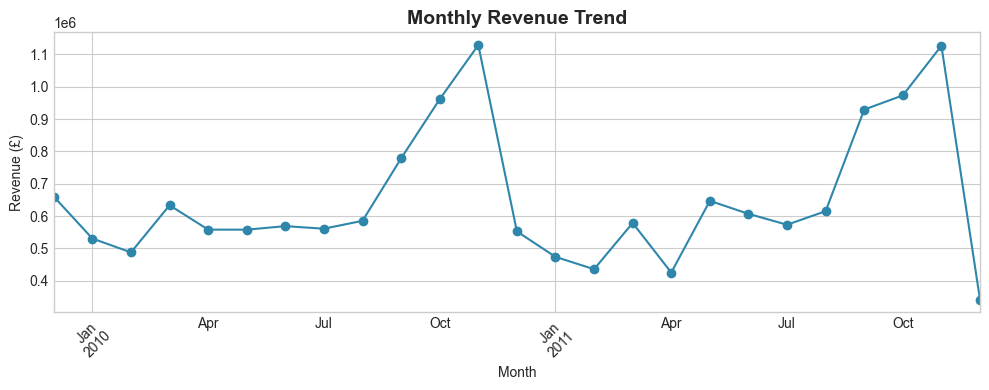

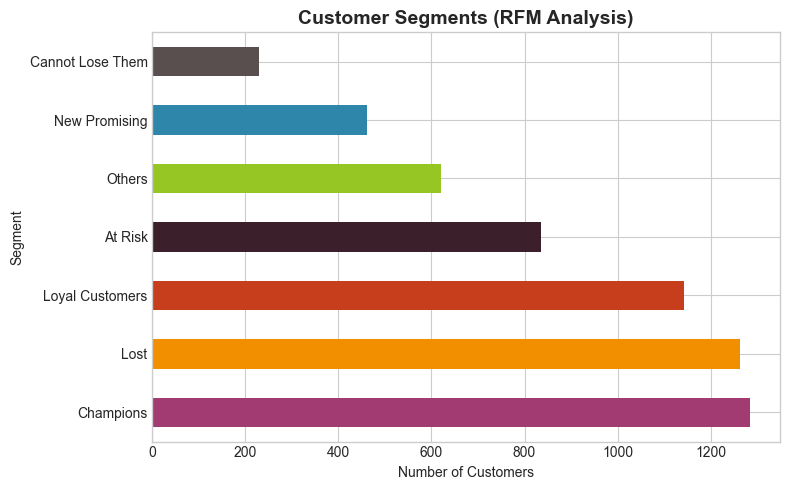

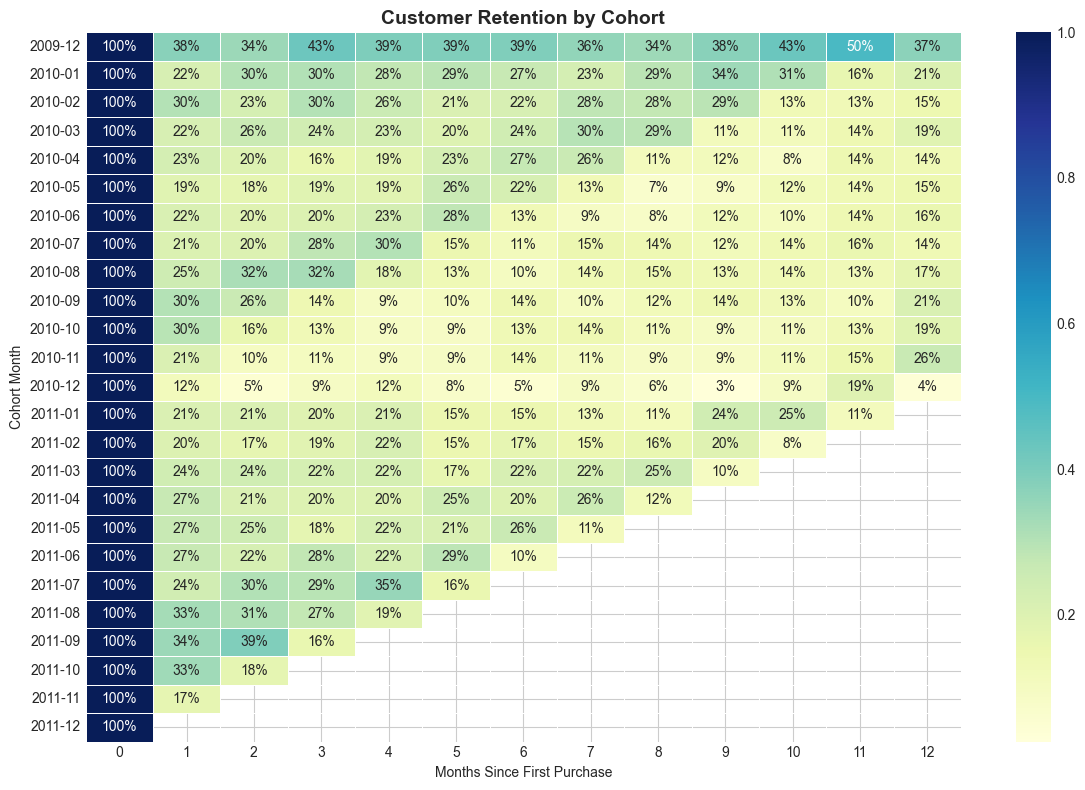

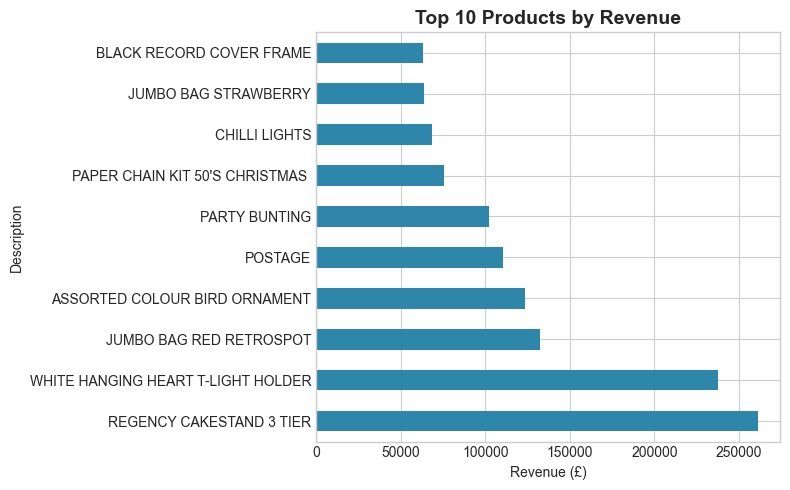

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make charts look cleaner in Jupyter
plt.style.use('seaborn-v0_8-whitegrid')  # or 'seaborn-v0_8-darkgrid'
sns.set_palette("husl")

# Chart 1: Monthly Revenue Trend
monthly_revenue = df_clean.groupby('InvoiceMonth')['Revenue'].sum()

plt.figure(figsize=(10, 4))
monthly_revenue.plot(kind='line', marker='o', color='#2E86AB')
plt.title('Monthly Revenue Trend', fontsize=14, weight='bold')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()

# Chart 2: RFM Segment Distribution
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))
segment_counts.plot(kind='barh', color=['#A23B72','#F18F01','#C73E1D','#3B1F2B','#95C623','#2E86AB','#594F4F'])
plt.title('Customer Segments (RFM Analysis)', fontsize=14, weight='bold')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150)
plt.show()

# Chart 3: Cohort Retention Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(retention_12, annot=True, fmt='.0%', cmap='YlGnBu', linewidths=0.5)
plt.title('Customer Retention by Cohort', fontsize=14, weight='bold')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=150)
plt.show()

# Chart 4: Top 10 Products by Revenue
top_products = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_products.plot(kind='barh', color='#2E86AB')
plt.title('Top 10 Products by Revenue', fontsize=14, weight='bold')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('top_products.png', dpi=150)
plt.show()

# Export the deliverable CSV
rfm.to_csv('rfm_segments.csv', index=False)
print("✅ Done! Check your notebook folder for:")
print("   - rfm_segments.csv (client deliverable)")
print("   - monthly_revenue.png")
print("   - rfm_segments.png")
print("   - cohort_retention.png")
print("   - top_products.png")

💡 Note: fmt='.0%' displays the heatmap values as percentages. Saving at 150 DPI keeps the images sharp while keeping file size reasonable. rfm_segments.csv is the exported customer level segment file.